# 1.3 Gaussian city

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create a city

2025-06-25 10:33:46,602 - INFO - Initializing city
2025-06-25 10:33:46,605 - INFO - Calculating density profile for 1 cores
2025-06-25 10:33:46,619 - INFO - Running simulation for 5000 steps
2025-06-25 10:33:50,537 - INFO - Simulation completed in 3.92 seconds
2025-06-25 10:33:50,538 - INFO - In-simulation time passed: 35 days
2025-06-25 10:33:50,538 - INFO - Statistics gathered over: 35 days
2025-06-25 10:33:50,540 - INFO - Cumulative rentals happened: 42760
2025-06-25 10:33:50,541 - INFO - Average rentals per car per day: 4.10
2025-06-25 10:33:50,543 - INFO - Average rental time per trip, min: 18.47
2025-06-25 10:33:50,544 - INFO - Average CM1 gain per trip, Eur: 4.62
2025-06-25 10:33:50,545 - INFO - Overall CM2 profit per day, Eur: -225.09


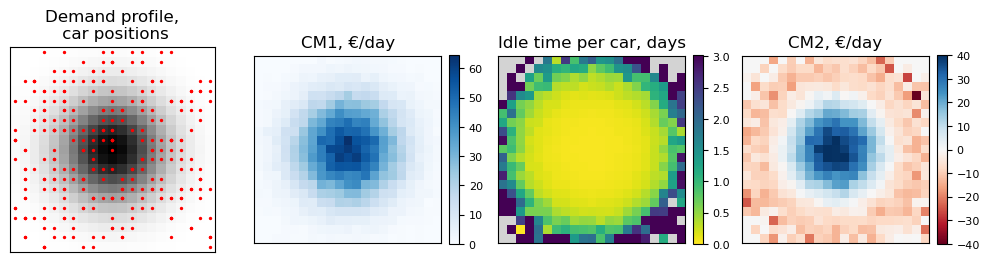

In [4]:
# Testing grounds, not a real figure
config = {
    "seed": 1,  # Random seed
    "city_width": 21, # km 
    "grid_step": 1, 
    "density_sigma": 5, # Gaussian sigma,
    "n_cores": 1,
    "n_cars": 300, 
    "settle_down_steps": 1000, # Number of steps without stats collection, for the system to settle down
    "p_rental": 0.18,  # Fine-tuned to make a city break even
}

import matplotlib.pyplot as plt
from city_simulator import City

city = City(config)
city.init_cars()
city.simulate(5000)
plt.figure(figsize=(10, 5))
city.visualize()

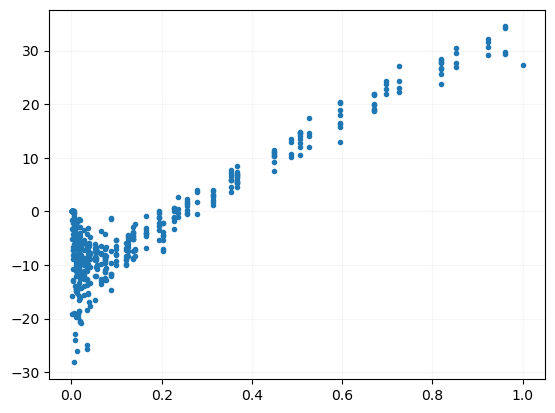

In [6]:
plt.plot(city.demand.flatten(), city.stats_cm2.flatten() / city.n_days, '.')
plt.grid(alpha=0.1)

# Introduction to Gaussian City

2025-06-25 09:25:46,866 - INFO - Initializing city
2025-06-25 09:25:46,868 - INFO - Calculating density profile for 1 cores


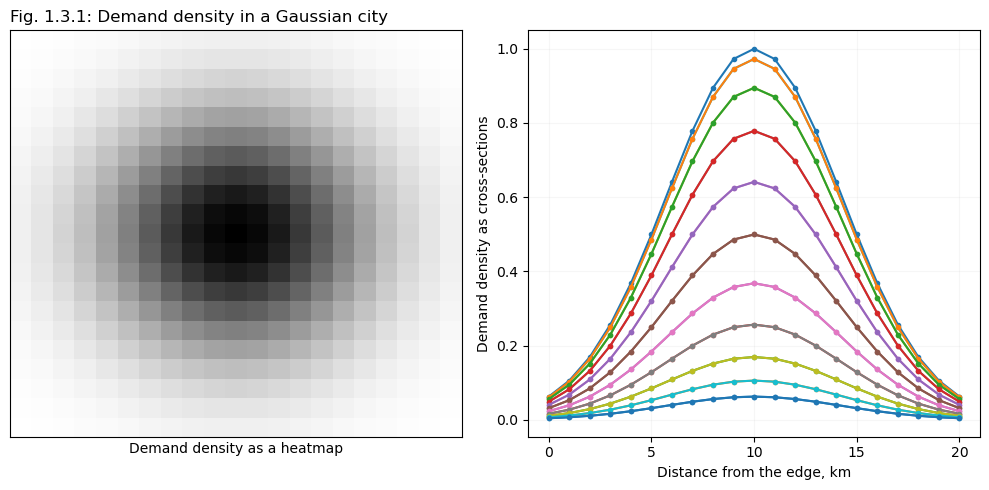

In [7]:
# Population density
config = {
    "seed": 1,  # Random seed
    "city_width": 21, # km 
    "grid_step": 1, 
    "density_sigma": 6, # Gaussian sigma,
}

city = City(config)

# Visualize the city
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(city.demand.T, aspect='auto', interpolation='none',
          extent=[0, city.grid_size, 0, city.grid_size], cmap='gray_r', vmin=0, vmax=1);
plt.xlabel('Demand density as a heatmap')
plt.xticks([], [])
plt.yticks([], [])
plt.title("Fig. 1.3.1: Demand density in a Gaussian city", loc='left')

plt.subplot(122);
plt.plot(np.arange(city.grid_size)*config["grid_step"], city.demand, '.-');
plt.grid(alpha=0.1)
plt.xticks([0, 5, 10, 15, 20])
plt.xlabel('Distance from the edge, km')
plt.ylabel('Demand density as cross-sections')

plt.tight_layout()
plt.savefig("../figures/01simple_03city_01population.svg", dpi=300)

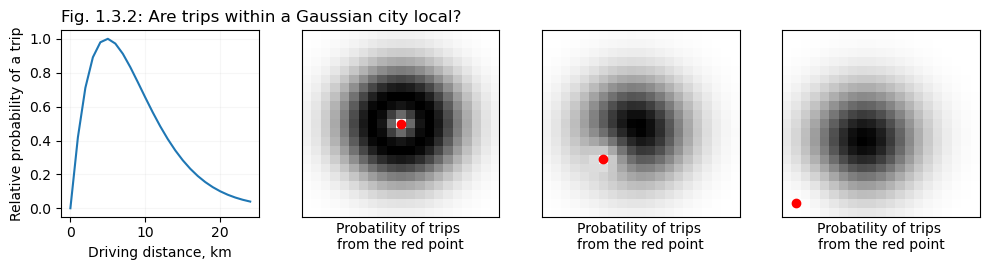

In [9]:
# Spatial mobility curve

n_grid = city.grid_size
density = city.demand

def trip_probability(distance):
    y = distance*np.exp(-(distance**1.2)/8) / 2.11
    return y

x = np.arange(0, 25)
curve = trip_probability(x)

def generate_local_map(i0, j0):
    local_trips = np.zeros(shape=(n_grid, n_grid))
    for i in range(n_grid):
        for j in range(n_grid):
            distance = np.sqrt((i-i0)**2 + (j-j0)**2)*config["grid_step"]        
            local_trips[i, j] = trip_probability(distance)
    local_trips *= density
    local_trips /= local_trips.flatten().max()
    return local_trips

# Figure
plt.figure(figsize=(10, 2.8))
plt.subplot(141)
plt.plot(x, curve)
plt.grid(alpha=0.1)
plt.xlabel('Driving distance, km')
plt.ylabel('Relative probability of a trip')
plt.title("Fig. 1.3.2: Are trips within a Gaussian city local?", loc='left');

plt.subplot(142)
plt.imshow(generate_local_map(10, 10).T, aspect='auto', interpolation='none',
          extent=[0, n_grid, 0, n_grid], cmap='gray_r', vmin=0, vmax=1, origin='lower');
plt.plot(10+0.5, 10+0.5, 'ro')
plt.tight_layout()
plt.xticks([], [])
plt.yticks([], [])
plt.xlabel("Probatility of trips \nfrom the red point")

plt.subplot(143)
plt.imshow(generate_local_map(6, 6).T, aspect='auto', interpolation='none',
          extent=[0, n_grid, 0, n_grid], cmap='gray_r', vmin=0, vmax=1, origin='lower');
plt.plot(6+0.5, 6+0.5, 'ro')
plt.tight_layout()
plt.xticks([], [])
plt.yticks([], [])
plt.xlabel("Probatility of trips \nfrom the red point")

plt.subplot(144)
plt.imshow(generate_local_map(1, 1).T, aspect='auto', interpolation='none',
          extent=[0, n_grid, 0, n_grid], cmap='gray_r', vmin=0, vmax=1, origin='lower');
plt.plot(1+0.5, 1+0.5, 'ro')
plt.tight_layout()
plt.xticks([], [])
plt.yticks([], [])
plt.xlabel("Probatility of trips \nfrom the red point")

plt.savefig("../figures/01simple_03city_02mobility.svg", dpi=300)

# Final distribution of cars

2025-06-25 09:26:42,807 - INFO - Initializing city
2025-06-25 09:26:42,812 - INFO - Calculating density profile for 1 cores
2025-06-25 09:26:42,952 - INFO - Running simulation for 5 steps
2025-06-25 09:26:42,983 - INFO - Simulation completed in 0.03 seconds
2025-06-25 09:26:42,987 - INFO - In-simulation time passed: 0 days
2025-06-25 09:26:42,989 - INFO - Cumulative rentals happened: 284
2025-06-25 09:26:42,991 - INFO - Average rentals per car per day: 16.36
2025-06-25 09:26:43,089 - INFO - Running simulation for 3000 steps
2025-06-25 09:26:46,798 - INFO - Simulation completed in 3.70 seconds
2025-06-25 09:26:46,799 - INFO - In-simulation time passed: 21 days
2025-06-25 09:26:46,801 - INFO - Cumulative rentals happened: 86066
2025-06-25 09:26:46,802 - INFO - Average rentals per car per day: 8.25


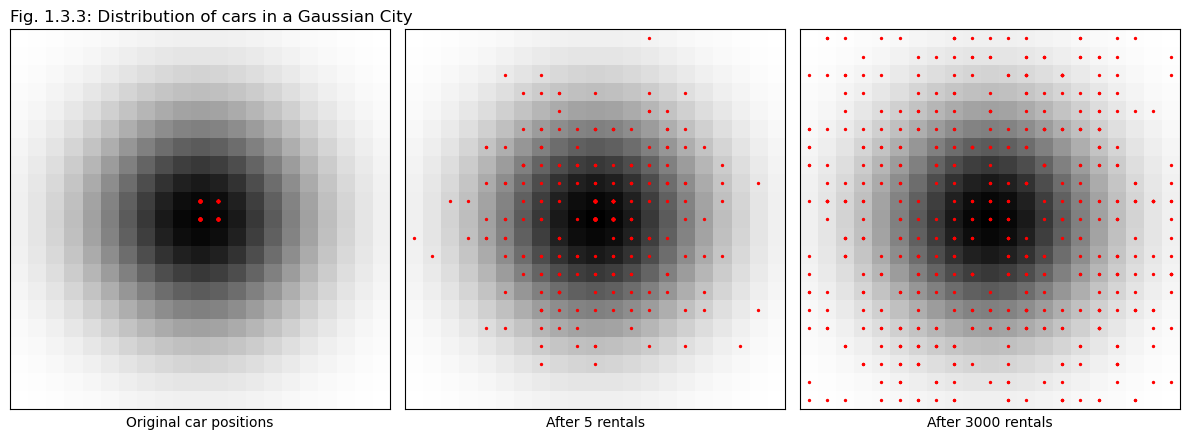

In [10]:
# Evolution of car distribution
config = {
    "seed": 2,  # Random seed
    "city_width": 21, # km 
    "grid_step": 1,     
    "n_cars": 500, 
    "initial_r": 1,
    "density_sigma": 6,
}

import matplotlib.pyplot as plt
from city_simulator import City

city = City(config)
city.init_cars()
plt.figure(figsize=(12, 5))
plt.subplot(131)
city.visualize("cars")
plt.xlabel("Original car positions")
plt.title("Fig. 1.3.3: Distribution of cars in a Gaussian City", loc='left');
city.simulate(5)
plt.subplot(132)
city.visualize("cars")
plt.xlabel("After 5 rentals")
city.simulate(3000)
plt.subplot(133)
city.visualize("cars")
plt.xlabel("After 3000 rentals");
plt.savefig("../figures/01simple_03city_03cardistribution.svg", dpi=300)

# Typical statistics - base state

2025-06-25 10:37:06,975 - INFO - Initializing city
2025-06-25 10:37:06,980 - INFO - Calculating density profile for 1 cores
2025-06-25 10:37:07,012 - INFO - Running simulation for 5000 steps
2025-06-25 10:37:11,432 - INFO - Simulation completed in 4.42 seconds
2025-06-25 10:37:11,434 - INFO - In-simulation time passed: 35 days
2025-06-25 10:37:11,435 - INFO - Statistics gathered over: 35 days
2025-06-25 10:37:11,437 - INFO - Cumulative rentals happened: 41162
2025-06-25 10:37:11,438 - INFO - Average rentals per car per day: 3.95
2025-06-25 10:37:11,439 - INFO - Average rental time per trip, min: 18.45
2025-06-25 10:37:11,441 - INFO - Average CM1 gain per trip, Eur: 4.61
2025-06-25 10:37:11,442 - INFO - Overall CM2 profit per day, Eur: -444.43


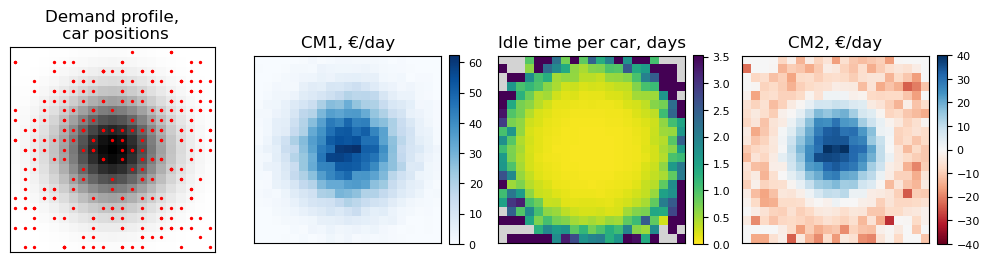

In [9]:
# Testing grounds, not a real figure
config = {
    "seed": 1,  # Random seed
    "city_width": 21, # km 
    "grid_step": 1, # km. Intermediate resolution
    "density_sigma": 5, # Gaussian sigma. A bit smaller than default, to have close-to-zero demands
    "n_cars": 300,
    "settle_down_steps": 1000, # Number of steps without stats collection, for the system to settle down
    "p_rental": 0.17,  # The simplest way to regulate trips/car/day and city profitability. This city is unprofitable
}

import matplotlib.pyplot as plt
from city_simulator import City

city = City(config)
city.init_cars()
city.simulate(5000)
plt.figure(figsize=(10, 5))
city.visualize()

Text(0, 0.5, 'Local CM2 per day, Eur')

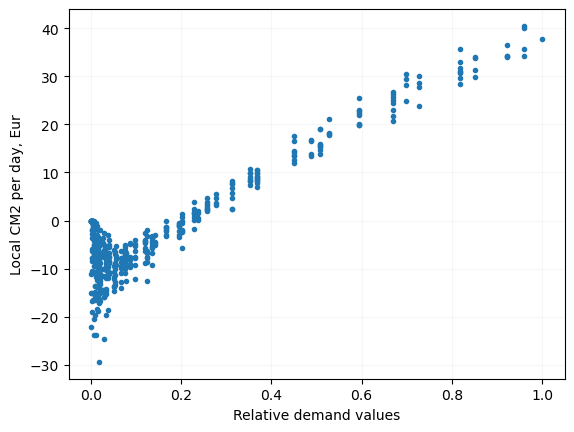

In [10]:
plt.plot(city.demand.flatten(), city.stats_cm2.flatten() / city.n_days, '.')
plt.grid(alpha=0.1)
plt.xlabel("Relative demand values")
plt.ylabel("Local CM2 per day, Eur")

# 🔥🔥🔥  Add CM1, idle times (as a function of demand)